# **Postprocessing of Run 5 over 100 epochs**

In [1]:
# Apply Autoreload so the script automatically detects changes in .py helper scripts

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import torch
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from pathlib import Path
from postprocessing import PostProcessing, DistributionEvaluator

In [3]:
project_root = Path.cwd().parents[2]
print(f"Project root directory: {project_root}")
base_datasets = project_root / "datasets" / "testing"
base_outputs = project_root / "outputs" / "post_training" / "20000_training_samples"
base_plots = project_root / "plots" / "post_training_plots"

# 1. FLUMY data directory
data_dir= base_datasets / "setting_2_nexus_1000_samples_ntg_67_chdepth_6_isbx_100" / "samples" / "facies" / "*.npy"

# 2. GAN data directories
gan_data_dir_best= base_outputs / "100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_08 = base_outputs / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_01 = base_outputs / "25_epochs_3_classes_cgan_num_iter_1_no_penalty_lr_gen_1e3_disc_3e3_doubleconv_on_setting_2" / "realizations" / "*.npy"

# 3. Output directories
out_dir_best = base_plots / "100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
out_dir_08 = base_plots / "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
output_dir_gan_01 = base_plots / "25_epochs_3_classes_cgan_num_iter_1_no_penalty_lr_gen_1e3_disc_3e3_doubleconv_on_setting_2"
os.makedirs(out_dir_best, exist_ok=True)

validators= []

run_configs = [("model 5: 100 epochs","Double conv + resblocks + disc penalty",out_dir_best, gan_data_dir_best),
               ("model 5: 25 epochs","Double conv + resblocks + disc penalty",out_dir_08, gan_data_dir_08)
               #("model 1: 25 epochs", "Standard model", output_dir_gan_01, gan_data_dir_01)
               ]

for gan_name, gan_description, out_dir, gan_path in run_configs:
    
    # 1. Create directories if they don't exist
    os.makedirs(out_dir, exist_ok=True)
    
    # 2. Initialize the validator
    validator = PostProcessing(
        flumy_name="setting 2",
        gan_name=gan_name,
        gan_description=gan_description,
        output_dir=out_dir,
        data_path=data_dir,
        gan_path=gan_path
    )
    
    # 2. Load the samples
    validator.load_flumy_samples(limit=100)
    validator.load_gan_samples(limit=100)
    validators.append(validator)

Project root directory: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading model 5: 100 epochs samples (limit: 100)...
Loaded 100 model 5: 100 epochs samples into memory.
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading model 5: 25 epochs samples (limit: 100)...
Loaded 100 model 5: 25 epochs samples into memory.


## **MS-SWD** 


Starting MS-SWD plotting progression...

Processing run: model 5: 100 epochs
Looking for CSV at: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\20000_training_samples\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_history.csv


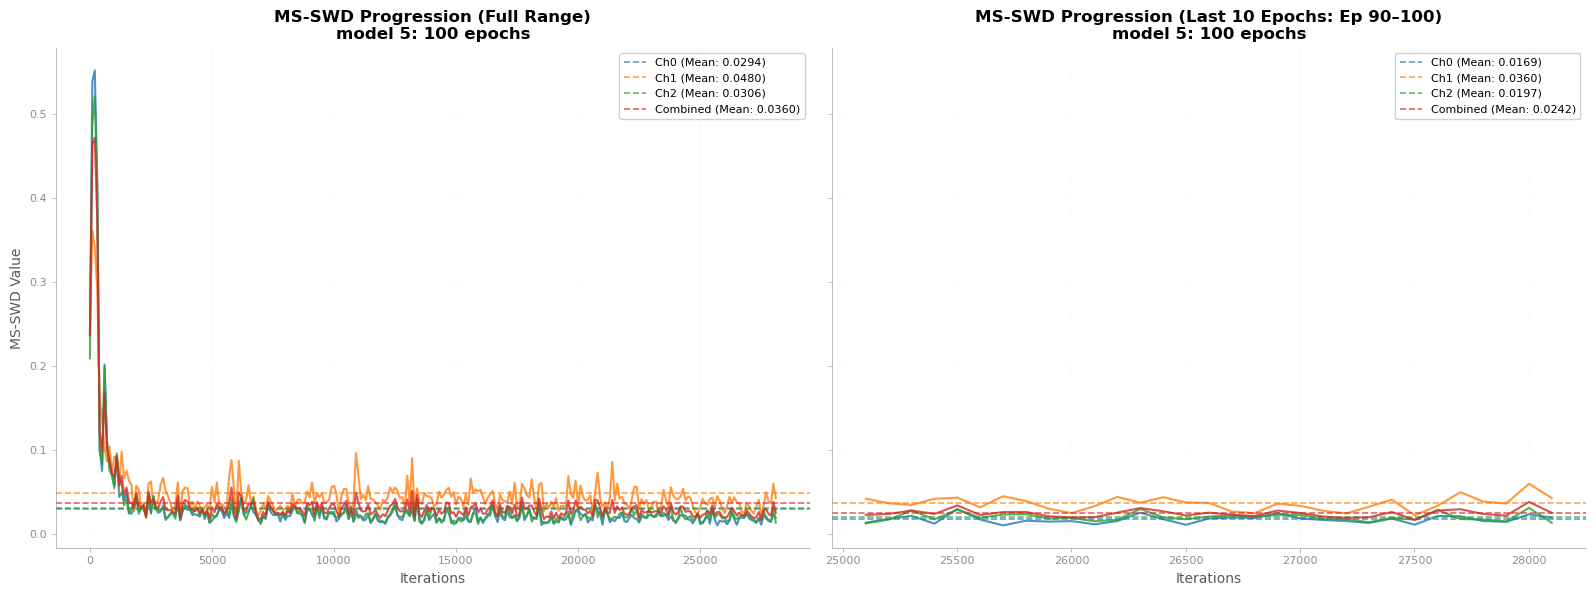

Successfully saved plot to: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\ms_swd_progression_model_5_100_epochs.png

Processing run: model 5: 25 epochs
Looking for CSV at: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\20000_training_samples\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_history.csv


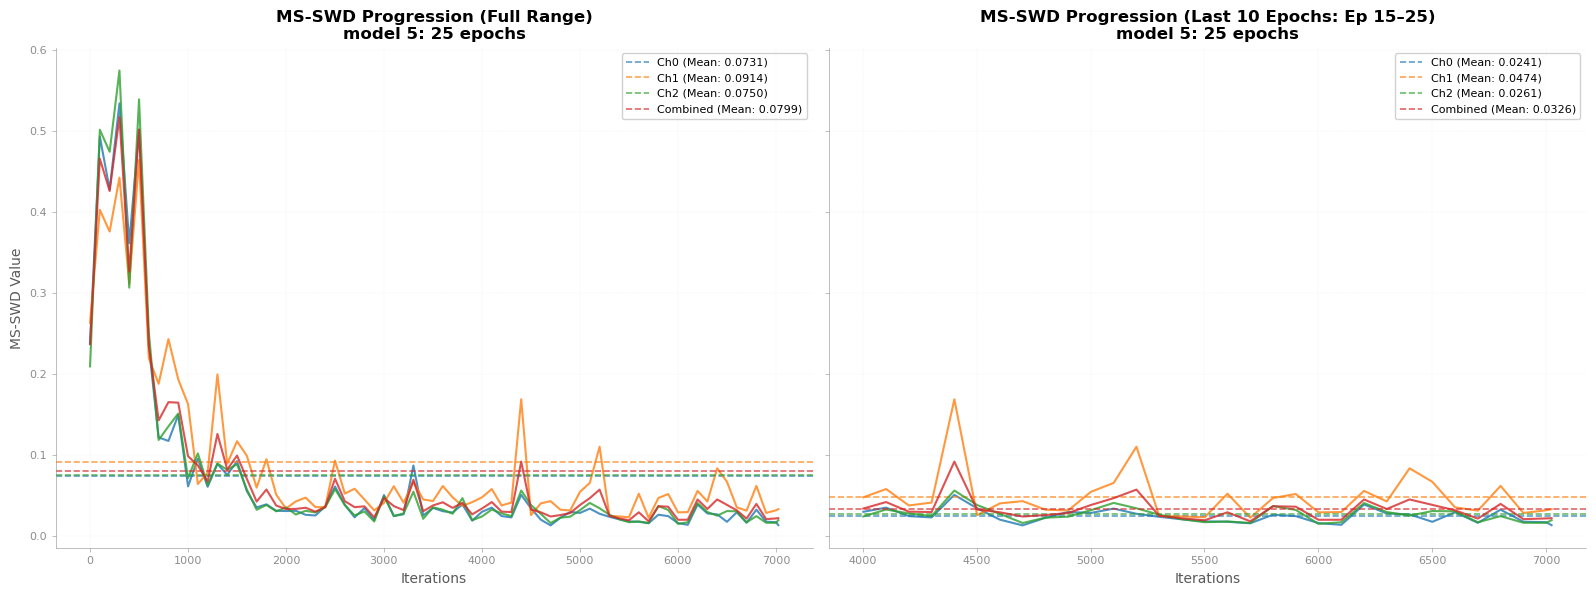

Successfully saved plot to: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\ms_swd_progression_model_5_25_epochs.png

All plots generated!


In [5]:
print("\nStarting MS-SWD plotting progression...")

# Filename of the history CSV located in the parent directory of 'realizations'
history_filename = "fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_history.csv"

for gan_name, gan_description, out_dir, gan_path in run_configs:
    # 1. Resolve paths
    gan_path = Path(gan_path)
    # The parent of '*.npy' is 'realizations', and its parent is the run directory
    run_dir = gan_path.parent.parent
    csv_path = run_dir / history_filename
    
    print(f"\nProcessing run: {gan_name}")
    print(f"Looking for CSV at: {csv_path}")
    
    if not csv_path.exists():
        print(f"⚠️ Warning: History file not found at {csv_path}. Skipping this run.")
        continue
        
    # 2. Read and clean the CSV
    df = pd.read_csv(csv_path)
    df.columns = [col.strip() for col in df.columns]  # Clean any accidental whitespace
    
    # Identify the epoch column (handles 'epochs' or 'epoch')
    epoch_col = 'epochs' if 'epochs' in df.columns else ('epoch' if 'epoch' in df.columns else None)
    
    if not epoch_col or 'iteration' not in df.columns:
        print(f"⚠️ Warning: Missing epoch/iteration columns in {csv_path}. Skipping.")
        continue
        
    # Standardize on the requested channels
    channels = ['MS-SWD_Ch0', 'MS-SWD_Ch1', 'MS-SWD_Ch2']
    missing_channels = [ch for ch in channels if ch not in df.columns]
    if missing_channels:
        print(f"⚠️ Warning: Missing columns {missing_channels} in CSV. Skipping.")
        continue
        
    # Drop rows where metrics weren't calculated (keeping only the periodic evaluations)
    df_metrics = df.dropna(subset=channels).copy()
    
    if df_metrics.empty:
        print(f"⚠️ Warning: No valid metric calculations found in {csv_path}. Skipping.")
        continue
        
    # Calculate the combined channel mean across the 3 channels
    df_metrics['MS-SWD_Combined'] = df_metrics[channels].mean(axis=1)
    all_metrics = channels + ['MS-SWD_Combined']
    
    # 3. Filter data for the last 10 epochs
    max_epoch = df_metrics[epoch_col].max()
    df_last_10 = df_metrics[df_metrics[epoch_col] >= (max_epoch - 10)].copy()
    
    # Define aesthetic colors for the channels
    colors = {
        'MS-SWD_Ch0': '#1f77b4',       # Blue
        'MS-SWD_Ch1': '#ff7f0e',       # Orange
        'MS-SWD_Ch2': '#2ca02c',       # Green
        'MS-SWD_Combined': '#d62728'  # Red
    }
    
    # 4. Set up the plotting grid (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # --- SUBPLOT 1: FULL RANGE ---
    ax1 = axes[0]
    for col in all_metrics:
        label_short = col.replace('MS-SWD_', '')
        mean_val = df_metrics[col].mean()
        color = colors[col]
        
        # Plot raw trajectory
        ax1.plot(df_metrics['iteration'], df_metrics[col], color=color, linewidth=1.5, alpha=0.8)
        # Plot horizontal mean line
        ax1.axhline(mean_val, color=color, linestyle='--', linewidth=1.2, alpha=0.7,
                    label=f"{label_short} (Mean: {mean_val:.4f})")
        
    ax1.set_title(f"MS-SWD Progression (Full Range)\n{gan_name}", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Iterations", fontsize=10)
    ax1.set_ylabel("MS-SWD Value", fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    
    # --- SUBPLOT 2: LAST 10 EPOCHS ---
    ax2 = axes[1]
    if not df_last_10.empty:
        for col in all_metrics:
            label_short = col.replace('MS-SWD_', '')
            mean_val_l10 = df_last_10[col].mean()
            color = colors[col]
            
            # Plot raw trajectory
            ax2.plot(df_last_10['iteration'], df_last_10[col], color=color, linewidth=1.5, alpha=0.8)
            # Plot horizontal mean line over last 10 epochs
            ax2.axhline(mean_val_l10, color=color, linestyle='--', linewidth=1.2, alpha=0.7,
                        label=f"{label_short} (Mean: {mean_val_l10:.4f})")
            
        ax2.set_title(f"MS-SWD Progression (Last 10 Epochs: Ep {int(max_epoch-10)}–{int(max_epoch)})\n{gan_name}", fontsize=12, fontweight='bold')
        ax2.set_xlabel("Iterations", fontsize=10)
        ax2.grid(True, linestyle=':', alpha=0.6)
        ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    else:
        ax2.text(0.5, 0.5, "Not enough data for\nlast 10 epochs evaluation", 
                 ha='center', va='center', transform=ax2.transAxes, color='gray')
        ax2.set_title("MS-SWD Progression (Last 10 Epochs)", fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    
    # 5. Save the plot to the specific run directory
    os.makedirs(out_dir, exist_ok=True)
    sanitized_name = gan_name.lower().replace(":", "").replace(" ", "_")
    plot_path = Path(out_dir) / f"ms_swd_progression_{sanitized_name}.png"
    
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Successfully saved plot to: {plot_path}")

print("\nAll plots generated!")

## **Global facies proportions**


--- Generating Facies Distribution (Mode: BOTH) ---
saved both facies percentages plot to: 
c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\facies_distribution_both.png


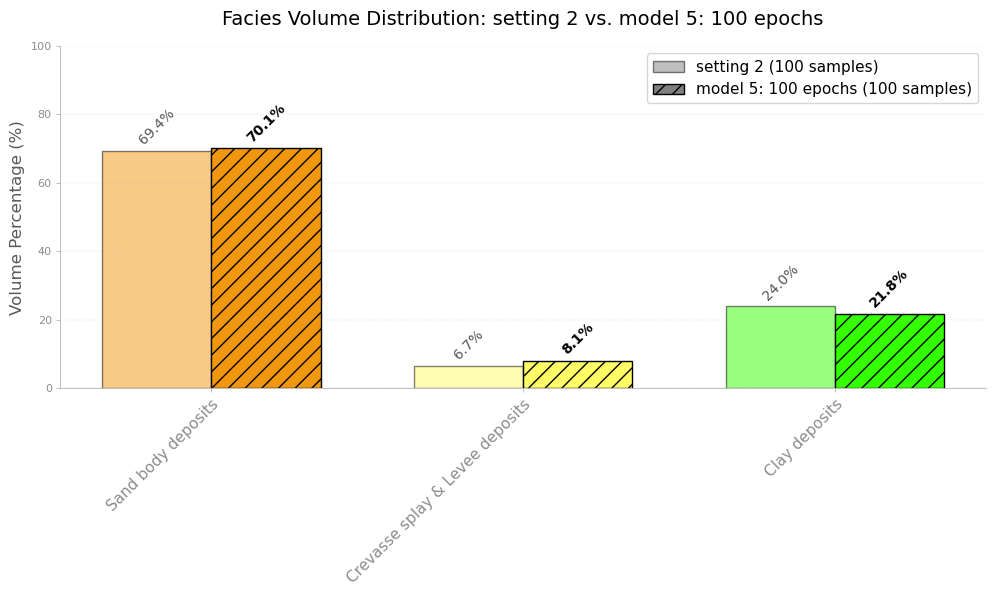


--- Generating Facies Distribution (Mode: BOTH) ---
saved both facies percentages plot to: 
c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\facies_distribution_both.png


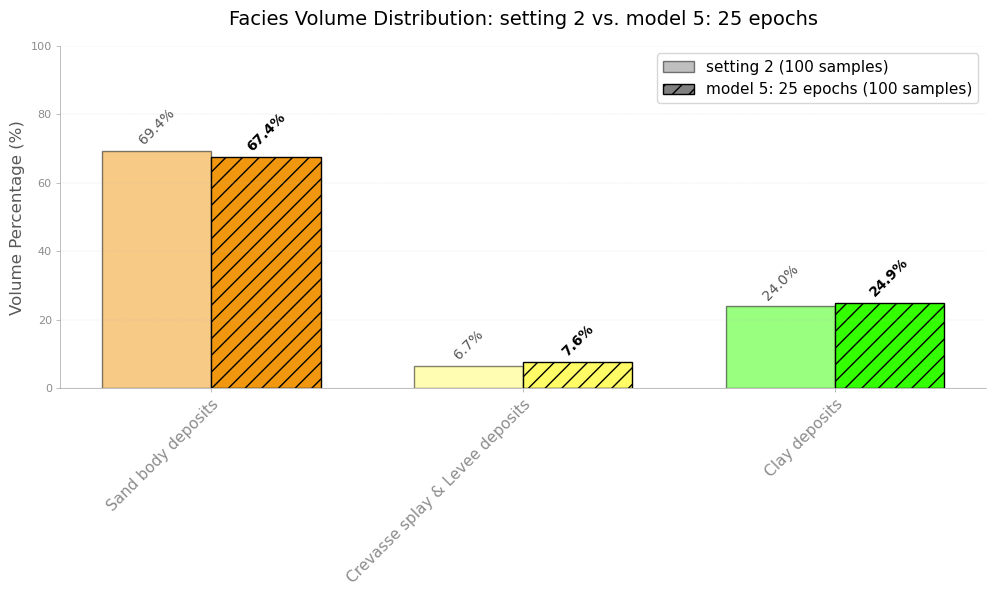

In [4]:
for i, validator in enumerate(validators):
    validator.plot_facies_percentages(mode='both', show_plot=True, save_plot=True)

# **1. Visualization**

## **1.1 2D visualization of samples**

Plotting 2d slices of FLUMY test dataset
Saved combined 2D grid matrix to: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_flumy_X_3samples.png


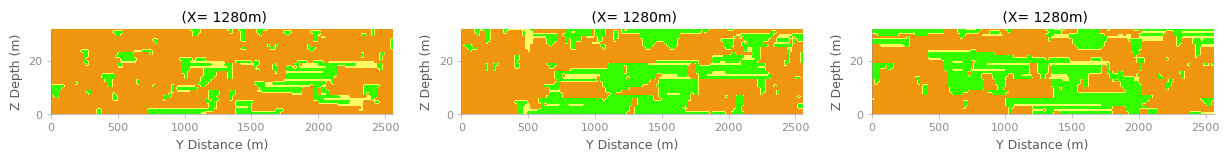

Saved combined 2D grid matrix to: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_flumy_Y_3samples.png


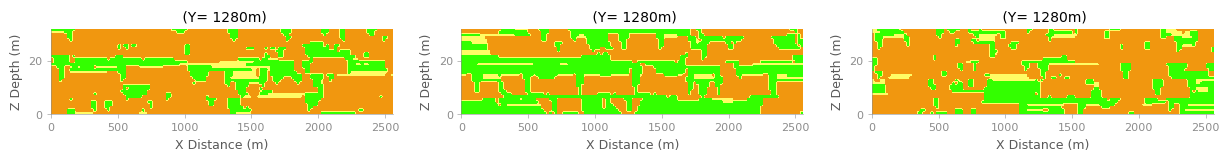

Saved combined 2D grid matrix to: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_gan_X_3samples.png


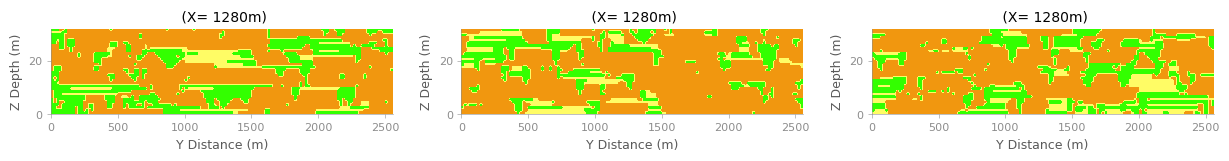

Saved combined 2D grid matrix to: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_gan_Y_3samples.png


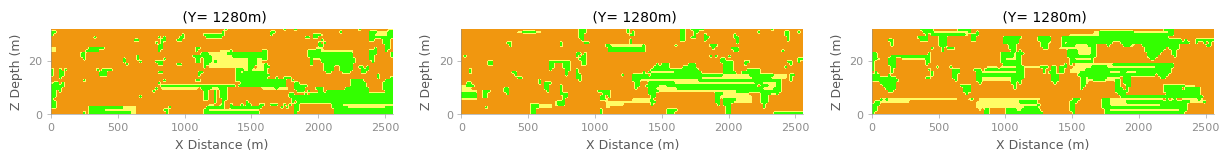

Saved combined 2D grid matrix to: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_gan_X_3samples.png


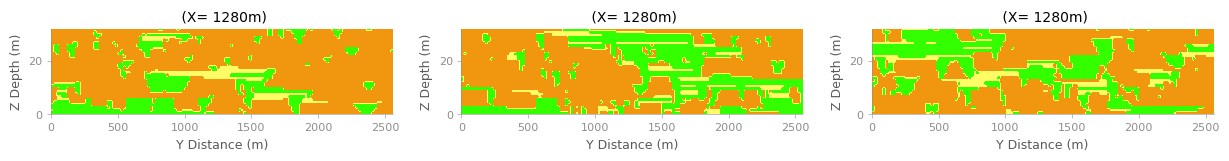

Saved combined 2D grid matrix to: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_gan_Y_3samples.png


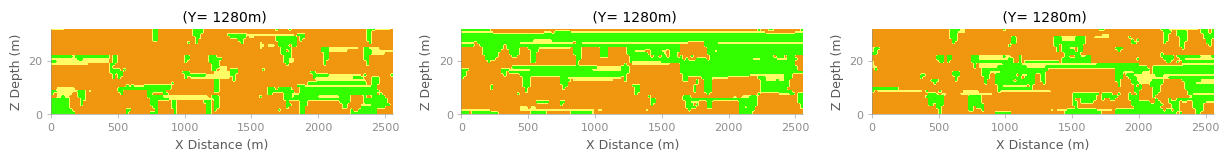

In [5]:
for i, validator in enumerate(validators):
    if i ==0:
        print(f"Plotting 2d slices of FLUMY test dataset")
        validator.plot_2d_slices(data_source='flumy', axis="X", show_legend=False, plot_filename=False, plot_title=False, num_samples=3, slice_indices=[64], save_plot=True)
        validator.plot_2d_slices(data_source='flumy', axis="Y", show_legend=False, plot_filename=False, plot_title=False, num_samples=3, slice_indices=[64], save_plot=True)
    validator.plot_2d_slices(data_source='gan', axis="X", show_legend=False, plot_title=False, plot_filename=False, num_samples=3, slice_indices=[64], save_plot=True)
    validator.plot_2d_slices(data_source='gan', axis="Y", show_legend=False, plot_title=False, plot_filename=False, num_samples=3, slice_indices=[64], save_plot=True)

## **1.2 3D Visualization of samples**


--- Generating 3D PyVista Plot (setting 2 | Mode: COMBINED) ---


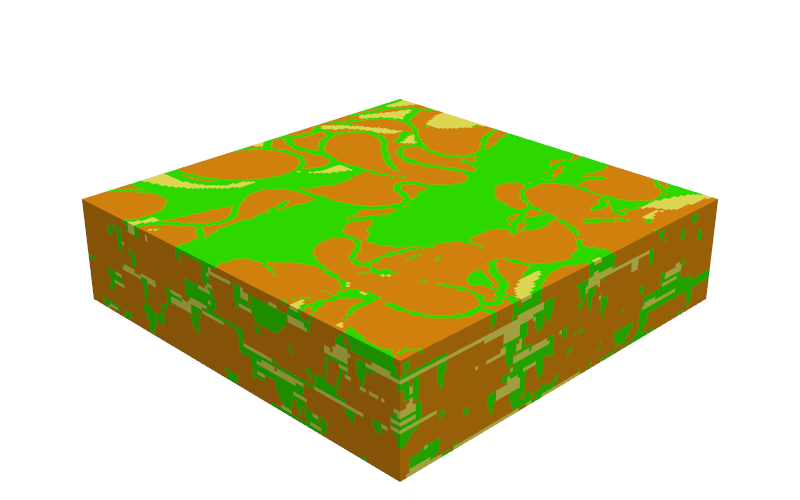


--- Generating 3D PyVista Plot (model 5: 100 epochs | Mode: COMBINED) ---


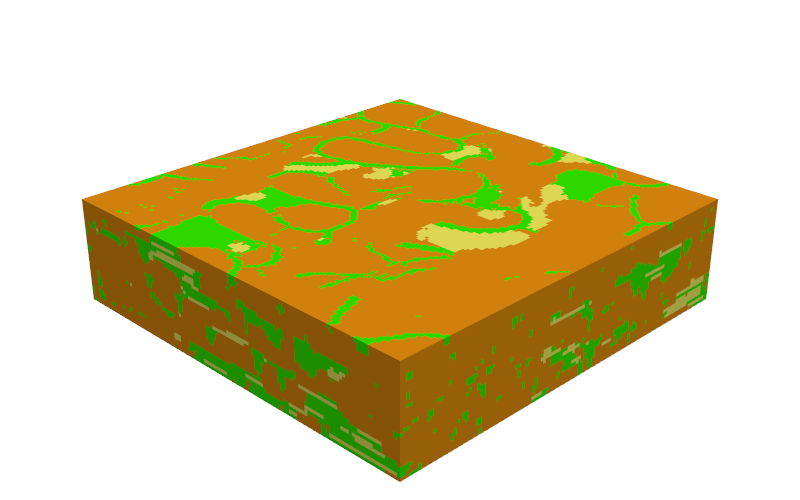


--- Generating 3D PyVista Plot (model 5: 25 epochs | Mode: COMBINED) ---


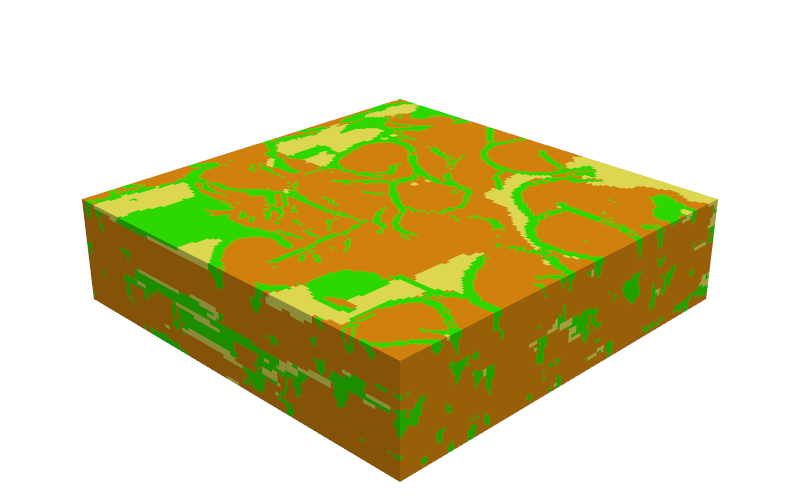

In [6]:
for i, validator in enumerate(validators):
    if i ==0:
        validator.plot_3d_pyvista(data_source='flumy', mode='combined', show_legend=False, show_plot=True, save_plot=False)
    validator.plot_3d_pyvista(data_source='gan', mode='combined', show_legend=False, show_plot=True, save_plot=False)

# **2. Voxel-wise entropy($H$)**

## **2.1 2D Voxel-wise $H$**

Plotting 2d slices of FLUMY test dataset

--- Generating setting 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


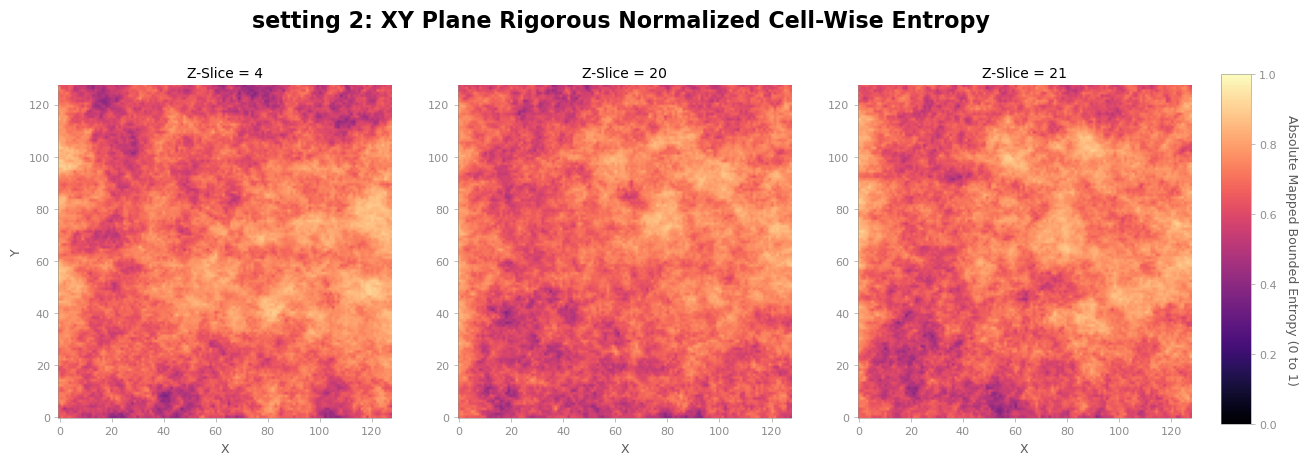


--- Generating setting 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


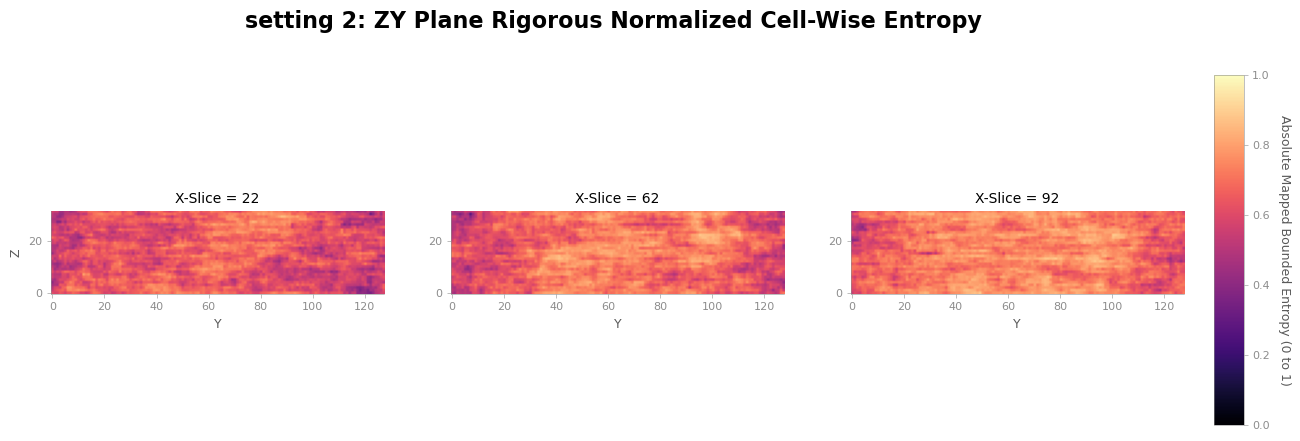


--- Generating setting 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


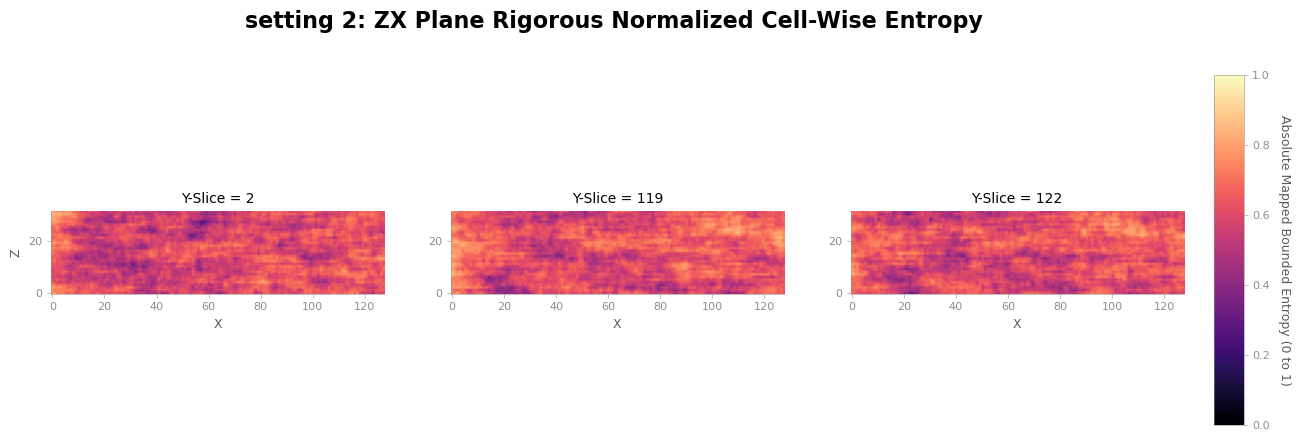


--- Generating model 5: 100 epochs Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


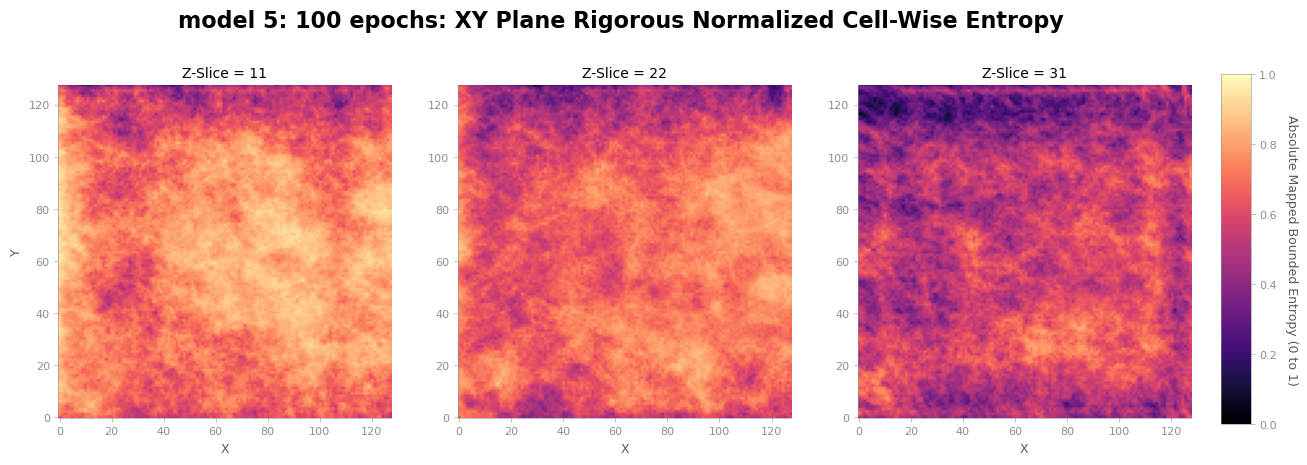


--- Generating model 5: 100 epochs Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


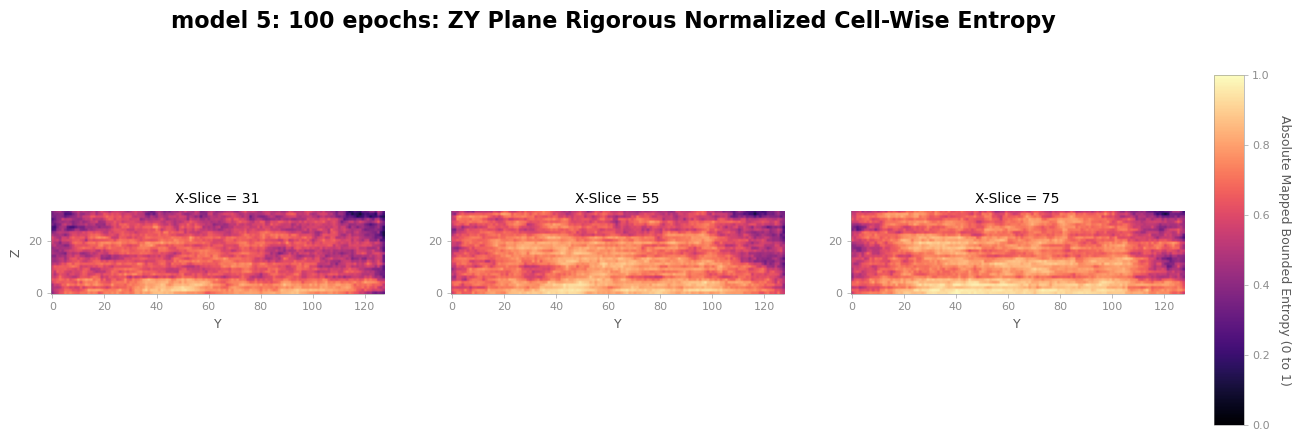


--- Generating model 5: 100 epochs Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


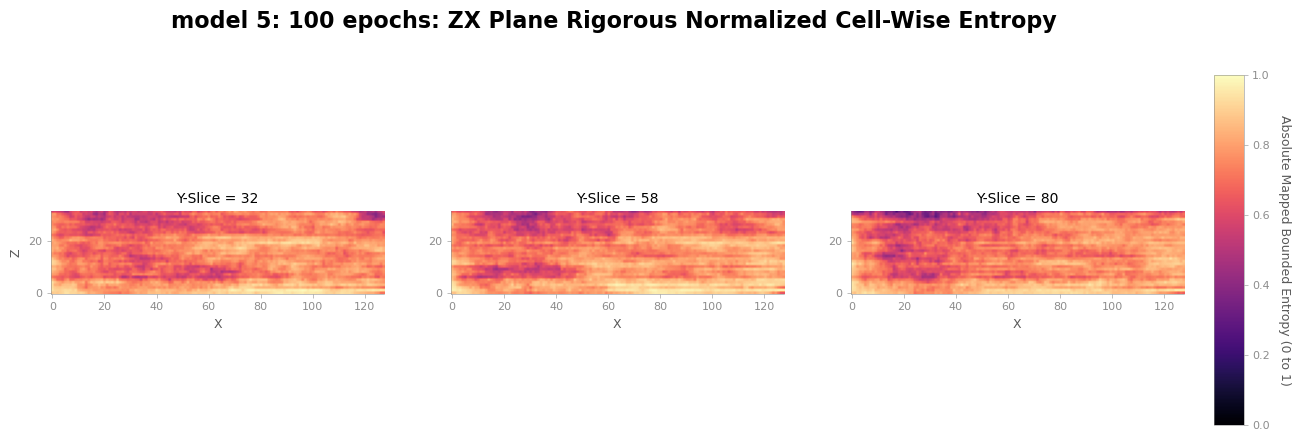


--- Generating model 5: 25 epochs Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


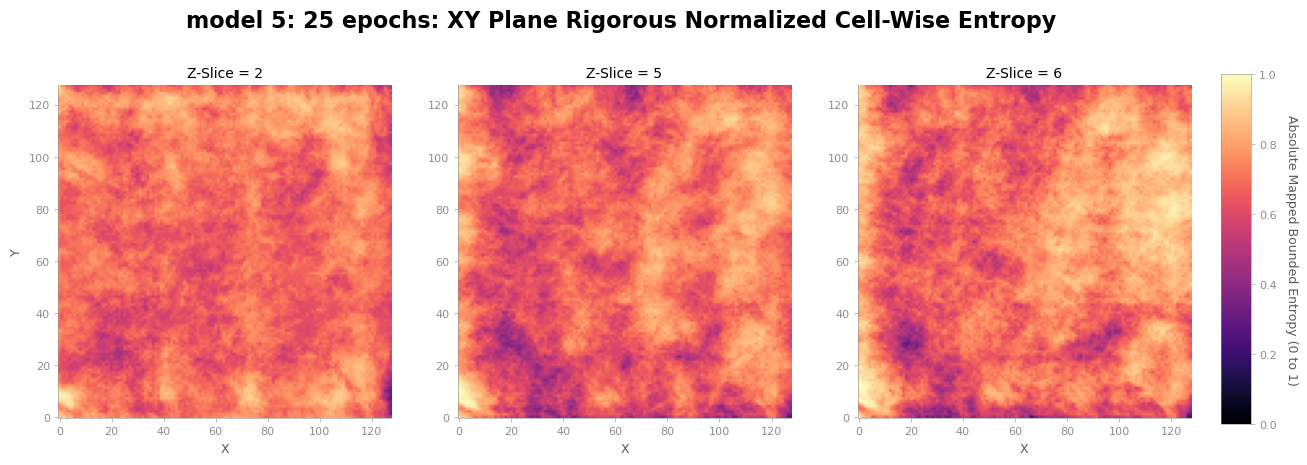


--- Generating model 5: 25 epochs Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


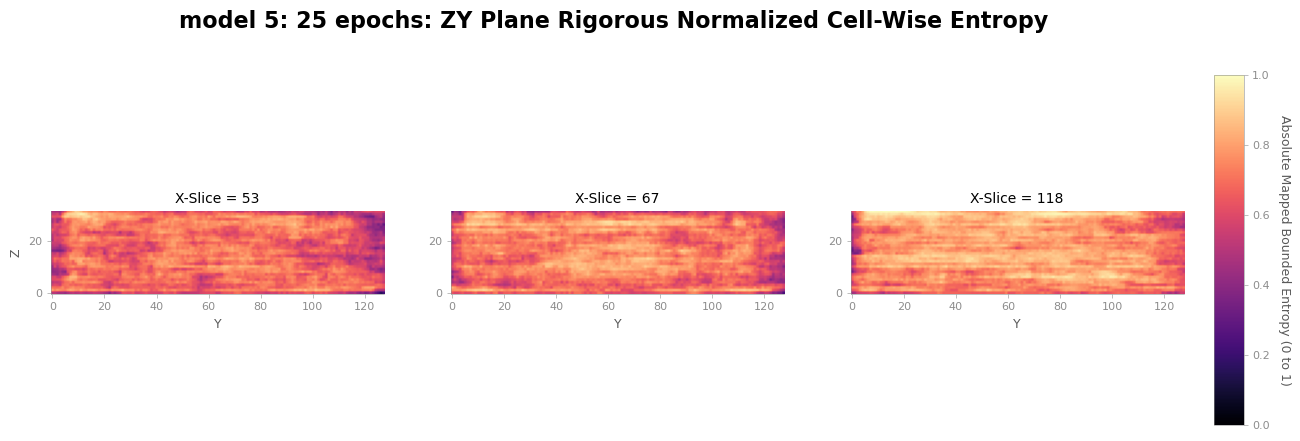


--- Generating model 5: 25 epochs Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


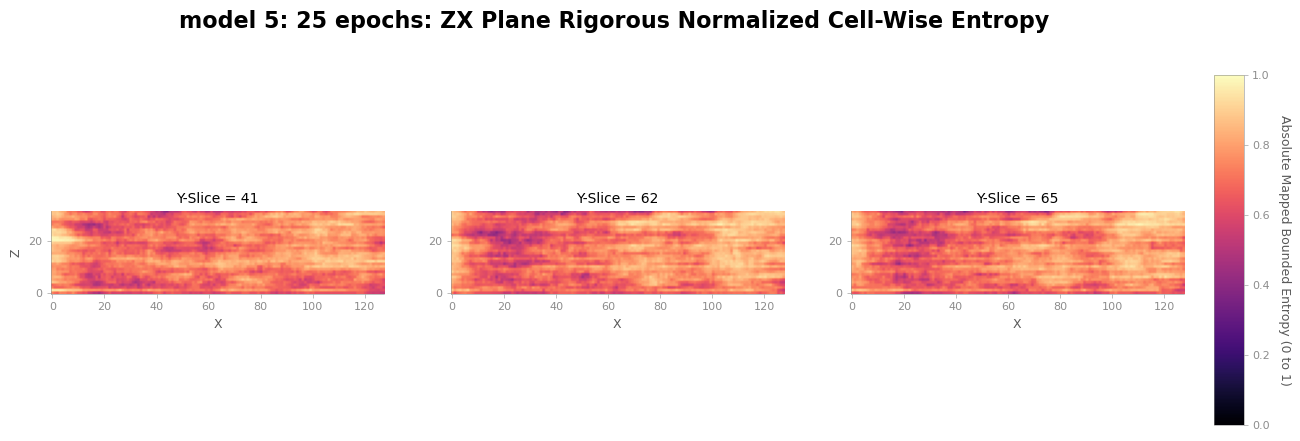

In [7]:
for i, validator in enumerate(validators):
    if i ==0:
        print(f"Plotting 2d slices of FLUMY test dataset")
        validator.plot_entropy(data_source='flumy', axis='Z', num_slices=3, save_plot=False)
        validator.plot_entropy(data_source='flumy', axis='X', num_slices=3, save_plot=False)
        validator.plot_entropy(data_source='flumy', axis='Y', num_slices=3, save_plot=False)

    validator.plot_entropy(data_source='gan', axis='Z', num_slices=3, save_plot=False)
    validator.plot_entropy(data_source='gan', axis='X', num_slices=3, save_plot=False)
    validator.plot_entropy(data_source='gan', axis='Y', num_slices=3, save_plot=False)

## **2.2 3D Voxel-wise entropy($H$)**


--- Generating 3D PyVista Entropy Map (setting 2) ---
[setting 2] Calculated Mean Voxel-Wise Entropy: 0.6922


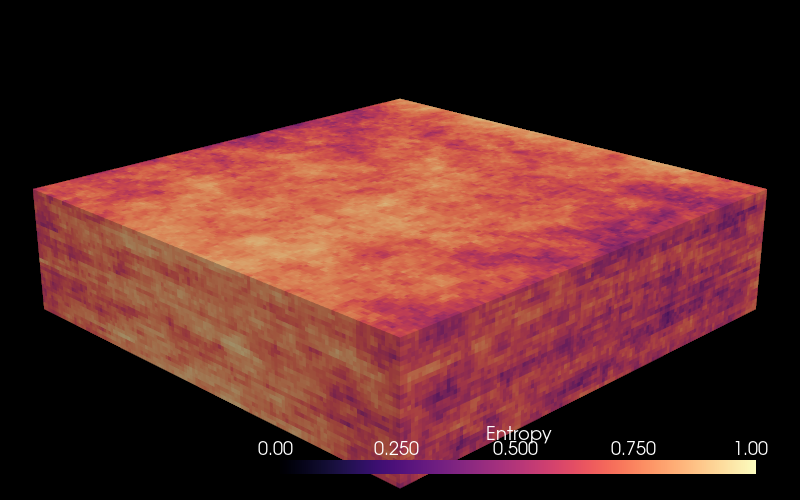


--- Generating 3D PyVista Entropy Map (model 5: 100 epochs) ---
[model 5: 100 epochs] Calculated Mean Voxel-Wise Entropy: 0.6841


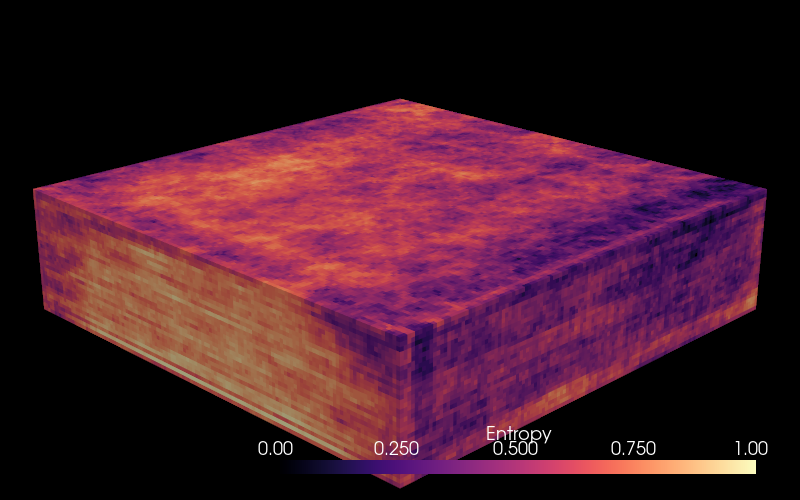


--- Generating 3D PyVista Entropy Map (model 5: 25 epochs) ---
[model 5: 25 epochs] Calculated Mean Voxel-Wise Entropy: 0.7037


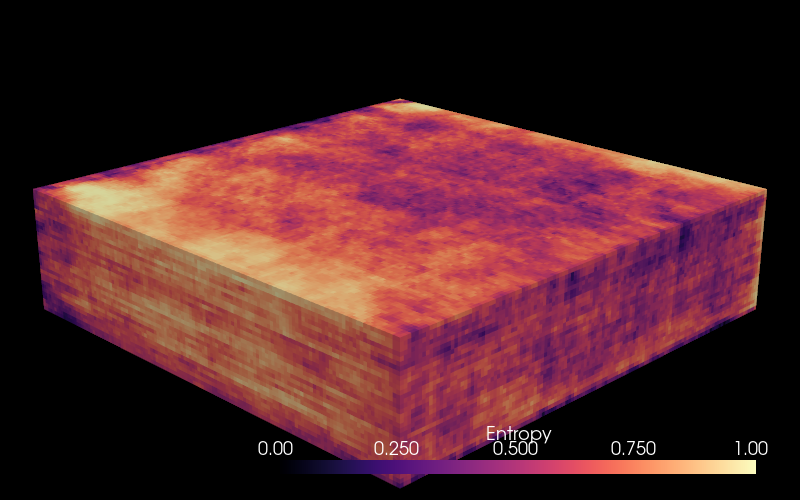

In [8]:
for i, validator in enumerate(validators):
    if i ==0:
        validator.plot_3d_entropy_pyvista(data_source='flumy', show_plot=True, save_plot=False)
    validator.plot_3d_entropy_pyvista(data_source='gan', show_plot=True, save_plot=False)

## **2.3 Jenson-Shannon Divergence**


--- Computing Scalar Metrics comparing model 5: 100 epochs to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
model 5: 100 epochs Model Entropy:  0.6841 ± 0.0697
Model-to-Baseline Spatial Entropy Ratio: 0.9883
Model-to-baseline JSD: 0.0132 ± 0.0061

--- Computing Scalar Metrics comparing model 5: 25 epochs to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
model 5: 25 epochs Model Entropy:  0.7037 ± 0.0330
Model-to-Baseline Spatial Entropy Ratio: 1.0166
Model-to-baseline JSD: 0.0146 ± 0.0073


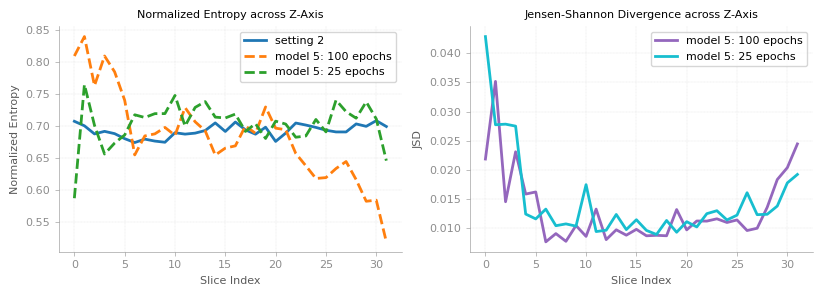


--- Computing Scalar Metrics comparing model 5: 100 epochs to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0381
model 5: 100 epochs Model Entropy:  0.6841 ± 0.0446
Model-to-Baseline Spatial Entropy Ratio: 0.9883
Model-to-baseline JSD: 0.0132 ± 0.0014

--- Computing Scalar Metrics comparing model 5: 25 epochs to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0381
model 5: 25 epochs Model Entropy:  0.7037 ± 0.0561
Model-to-Baseline Spatial Entropy Ratio: 1.0166
Model-to-baseline JSD: 0.0146 ± 0.0031


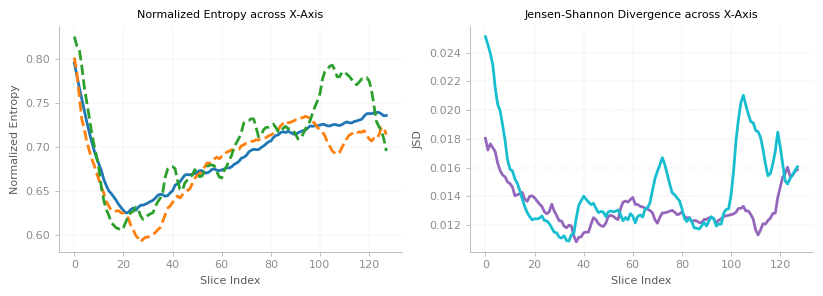


--- Computing Scalar Metrics comparing model 5: 100 epochs to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0461
model 5: 100 epochs Model Entropy:  0.6841 ± 0.0728
Model-to-Baseline Spatial Entropy Ratio: 0.9883
Model-to-baseline JSD: 0.0132 ± 0.0018

--- Computing Scalar Metrics comparing model 5: 25 epochs to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0461
model 5: 25 epochs Model Entropy:  0.7037 ± 0.0455
Model-to-Baseline Spatial Entropy Ratio: 1.0166
Model-to-baseline JSD: 0.0146 ± 0.0024


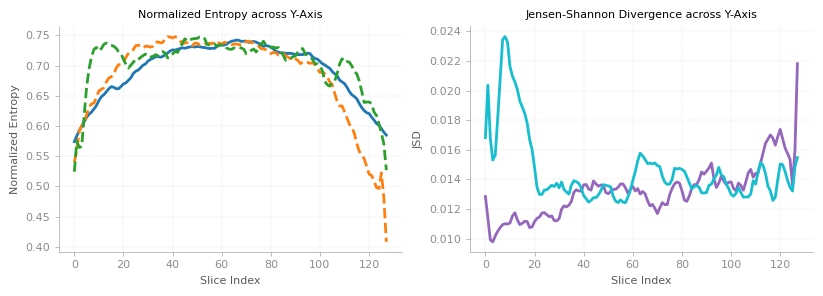

In [9]:
import matplotlib.pyplot as plt

axes_to_plot = ['Z', 'X', 'Y']

for i, axis in enumerate(axes_to_plot):
    fig, fig_axes = plt.subplots(1, 2, figsize=(8.27, 3))
    
    baseline_plotted = False
    gan_colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:brown']
    jsd_colors = ['tab:purple', 'tab:cyan', 'tab:pink', 'tab:olive']
    
    for idx, validator in enumerate(validators):
        df_results, _ = validator.compute_slice_metrics(axis=axis, plot=False)
        
        slices = df_results['Slice_Index']
        flumy_entropy = df_results['Flumy_Norm_Entropy']
        gan_entropy = df_results['GAN_Norm_Entropy']
        jsd = df_results['JSD_Flumy_vs_GAN']
        
        if not baseline_plotted:
            fig_axes[0].plot(slices, flumy_entropy, label=validator.flumy_name, color='tab:blue', linewidth=2)
            baseline_plotted = True
            
        g_color = gan_colors[idx % len(gan_colors)]
        fig_axes[0].plot(slices, gan_entropy, label=f'{validator.gan_name}', color=g_color, linewidth=2, linestyle='--')
        
        j_color = jsd_colors[idx % len(jsd_colors)]
        fig_axes[1].plot(slices, jsd, label=f'{validator.gan_name}', color=j_color, linewidth=2)
        
    fig_axes[0].set_title(f'Normalized Entropy across {axis}-Axis', fontsize=8)
    fig_axes[0].set_xlabel('Slice Index', fontsize=8)
    fig_axes[0].set_ylabel('Normalized Entropy', fontsize=8)
    if i ==0:
        fig_axes[0].legend(fontsize=8)
    fig_axes[0].grid(True, linestyle='--', alpha=0.7)
    
    fig_axes[1].set_title(f'Jensen-Shannon Divergence across {axis}-Axis', fontsize=8)
    fig_axes[1].set_xlabel('Slice Index', fontsize=8)
    fig_axes[1].set_ylabel('JSD', fontsize=8)
    if i == 0:
        fig_axes[1].legend(fontsize=8)
    fig_axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f'combined_H_and_JSD_metrics_axis_{axis}.png', dpi=300)
    plt.show()

# **3. Structural analysis metrics**

## **3.1 Connectivity analysis**


 TOTAL UNIQUE MPS PATTERNS (100 SAMPLES)
setting 2: 2,949,220 unique patterns
model 5: 100 epochs: 3,846,513 unique patterns
model 5: 25 epochs: 3,727,836 unique patterns



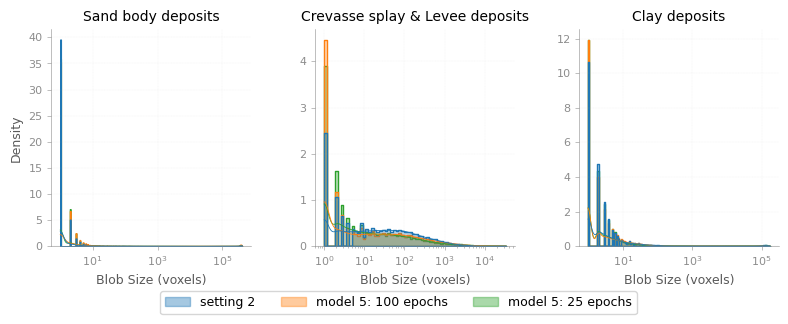

In [10]:
import gc
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

first_val = validators[0]
facies_list = first_val.cfg['codes']
flumy_name = first_val.flumy_name

blob_data_compiled = {f_val: {} for f_val in facies_list}
unique_pattern_counts = {}
baseline_patterns_computed = False

for validator in validators:
    if not getattr(validator, 'flumy_samples', None):
        validator.load_flumy_samples(limit=100)
    if not getattr(validator, 'gan_data', None):
        validator.load_gan_samples(limit=100)
        
    if not baseline_patterns_computed:
        flumy_pattern_set = set()
        for sample in validator.flumy_samples[:100]:
            patterns, _ = validator.get_pattern_counts(sample)
            for p in patterns:
                flumy_pattern_set.add(tuple(p))
        unique_pattern_counts[flumy_name] = len(flumy_pattern_set)
        del flumy_pattern_set
        gc.collect()
        baseline_patterns_computed = True

    gan_pattern_set = set()
    for sample in validator.gan_data[:100]:
        patterns, _ = validator.get_pattern_counts(sample)
        for p in patterns:
            gan_pattern_set.add(tuple(p))
    unique_pattern_counts[validator.gan_name] = len(gan_pattern_set)
    del gan_pattern_set
    gc.collect()
        
    for f_val in facies_list:
        if flumy_name not in blob_data_compiled[f_val]:
            flumy_blobs = []
            for sample in validator.flumy_samples[:100]:
                flumy_blobs.extend(validator.analyze_connectivity(sample, f_val))
            blob_data_compiled[f_val][flumy_name] = flumy_blobs
            
        gan_blobs = []
        for sample in validator.gan_data[:100]:
            gan_blobs.extend(validator.analyze_connectivity(sample, f_val))
        blob_data_compiled[f_val][validator.gan_name] = gan_blobs
        
    validator.flumy_samples = []
    validator.gan_data = []
    gc.collect()

print("\n" + "="*50)
print(" TOTAL UNIQUE MPS PATTERNS (100 SAMPLES)")
print("="*50)
for name, count in unique_pattern_counts.items():
    print(f"{name}: {count:,} unique patterns")
print("="*50 + "\n")

dataset_names = [flumy_name] + [v.gan_name for v in validators]
color_sequence = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
color_palette = {name: color_sequence[i % len(color_sequence)] for i, name in enumerate(dataset_names)}

fig, axes = plt.subplots(1, 3, figsize=(8.27, 3.5))

for idx, f_val in enumerate(facies_list):
    ax = axes[idx]
    facies_name = first_val.cfg['names'].get(f_val, f"Facies {f_val}")
    
    flat_list = []
    for d_name in dataset_names:
        for size in blob_data_compiled[f_val].get(d_name, []):
            flat_list.append({'Blob_Size': size, 'Dataset': d_name})
            
    df_blobs = pd.DataFrame(flat_list)
    
    if not df_blobs.empty:
        sns.histplot(
            data=df_blobs,
            x='Blob_Size',
            hue='Dataset',
            palette=color_palette,
            kde=True,
            element='step',
            stat='density',
            common_norm=False,
            alpha=0.3,
            ax=ax,
            log_scale=True,
            legend=False
        )
    
    ax.set_title(facies_name, fontsize=10)
    ax.set_xlabel("Blob Size (voxels)", fontsize=9)
    ax.set_ylabel("Density" if idx == 0 else "", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

fig.subplots_adjust(left=0.08, right=0.96, wspace=0.32, bottom=0.26, top=0.88)

legend_handles = [
    mpatches.Patch(color=color_palette[name], label=name, alpha=0.4) 
    for name in dataset_names
]

fig.legend(
    handles=legend_handles, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.15), 
    ncol=len(dataset_names), 
    frameon=True, 
    fontsize=9
)

plt.savefig("combined_models_facies_connectivity_analysis.png", dpi=300)
plt.show()

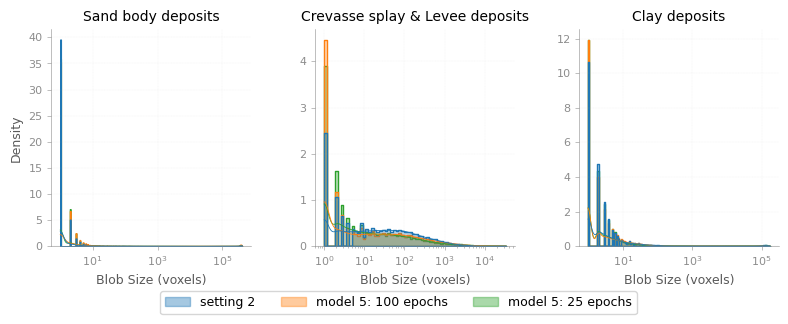

In [11]:
dataset_names = [flumy_name] + [v.gan_name for v in validators]
color_sequence = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
color_palette = {name: color_sequence[i % len(color_sequence)] for i, name in enumerate(dataset_names)}

fig, axes = plt.subplots(1, 3, figsize=(8.27, 3.5))

for idx, f_val in enumerate(facies_list):
    ax = axes[idx]
    facies_name = first_val.cfg['names'].get(f_val, f"Facies {f_val}")
    
    flat_list = []
    for d_name in dataset_names:
        for size in blob_data_compiled[f_val].get(d_name, []):
            flat_list.append({'Blob_Size': size, 'Dataset': d_name})
            
    df_blobs = pd.DataFrame(flat_list)
    
    if not df_blobs.empty:
        sns.histplot(
            data=df_blobs,
            x='Blob_Size',
            hue='Dataset',
            palette=color_palette,
            kde=True,
            element='step',
            stat='density',
            common_norm=False,
            alpha=0.3,
            ax=ax,
            log_scale=True,
            legend=False
        )
    
    ax.set_title(facies_name, fontsize=10)
    ax.set_xlabel("Blob Size (voxels)", fontsize=9)
    ax.set_ylabel("Density" if idx == 0 else "", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

fig.subplots_adjust(left=0.08, right=0.96, wspace=0.32, bottom=0.26, top=0.88)

legend_handles = [
    mpatches.Patch(color=color_palette[name], label=name, alpha=0.4) 
    for name in dataset_names
]

fig.legend(
    handles=legend_handles, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.15), 
    ncol=len(dataset_names), 
    frameon=True, 
    fontsize=9
)

plt.savefig("combined_models_facies_connectivity_analysis.png", dpi=300)
plt.show()

## **3.2 MDS plot of Multi-Scale Sliced Wasserstein Distance**

Successfully loaded 300 points from mds_2d_coordinates.csv


ValueError: 'center bottom' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

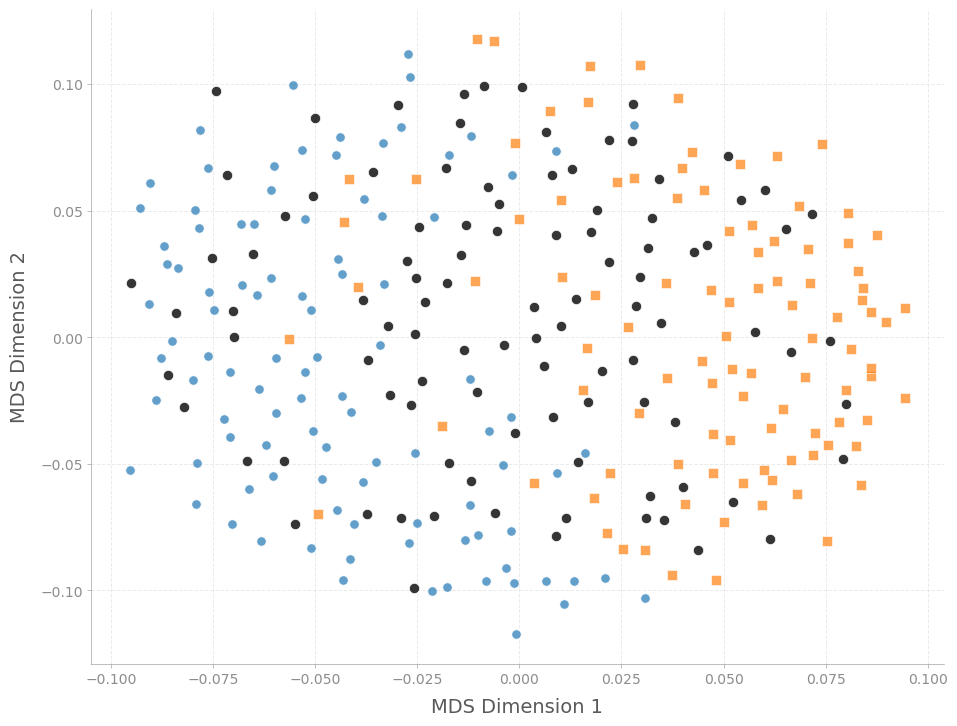

In [12]:
def plot_msswd_mds_projections(csv_path, save_path=None, figsize=(11, 8.5)):
    """
    Loads MDS coordinates from the cluster-generated CSV, applies the 
    defined style framework, and generates a 2D spatial clustering scatter plot.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Could not find coordinates CSV at: {csv_path}")
        
    # 1. Load Data
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded {len(df)} points from {os.path.basename(csv_path)}")
    
    # 2. Setup Plot Canvas
    fig, ax = plt.subplots(figsize=figsize)
    
    # Extract unique groups, pushing the ground truth baseline to the front of the line
    unique_labels = list(df['Label'].unique())
    real_labels = [l for l in unique_labels if 'real' in l.lower() or 'flumy' in l.lower()]
    model_labels = [l for l in unique_labels if l not in real_labels]
    ordered_labels = real_labels + model_labels
    
    # 3. Styling Configuration
    cmap = plt.get_cmap('tab10')
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']
    
    # 4. Iterative Group Plotting
    for i, label in enumerate(ordered_labels):
        group = df[df['Label'] == label]
        
        # Ground Truth gets a bold black marker
        if label in real_labels:
            color = '#111111'
            marker = 'o'
            display_name = "Flumy Ground Truth (Real)"
            size = 55
            alpha = 0.85
        else:
            # Models cycle dynamically through markers and colors
            color = cmap((i - len(real_labels)) % 10)
            marker = markers[(i - len(real_labels)) % len(markers)]
            size = 45
            alpha = 0.70
            
            # Optional: Clean up messy, long cluster filenames for the plot legend
            if "epochs_25" in label.lower():
                display_name = "GAN Run (25 Epochs)"
            elif "epochs_100" in label.lower():
                display_name = "GAN Run (100 Epochs)"
            else:
                display_name = label.replace("Model_", "Model ")
        
        ax.scatter(
            group['Dimension_1'], group['Dimension_2'],
            marker=marker, 
            color=color, 
            label=f"{display_name} (N={len(group)})",
            s=size, 
            alpha=alpha, 
            edgecolors='white', 
            linewidths=0.6,
            zorder=3 if label in real_labels else 2 # Keep real data points crisp on top
        )
        
    # 5. Presentation & Aesthetics
    # ax.set_title("Multi-Scale Sliced Wasserstein Distance (MS-SWD)\n2D MDS Spatial Structural Clustering", 
    #              fontsize=13, pad=15, fontweight='semibold')
    ax.set_xlabel("MDS Dimension 1", fontsize=14, labelpad=8)
    ax.set_ylabel("MDS Dimension 2", fontsize=14, labelpad=8)
    
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(color='#E2E2E2', alpha=0.7, linestyle='--', linewidth=0.7, zorder=1)
    
    # Position the legend completely outside the bounding box
    ax.legend(loc='center bottom', bbox_to_anchor=(1.03, 0.5), frameon=True, facecolor='white', edgecolor='#E2E2E2', fontsize=14)
    
    # Layout adjustment to make space for the external legend
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=400)
        print(f" Saved high-resolution MDS plot to: {save_path}")
        
    plt.show()

# --- Example Execution (Run this on your local laptop) ---
if __name__ == "__main__":
    # Point these to the local directories where you downloaded the cluster outputs
    local_csv_path = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\combined_mds_analysis\mds_2d_coordinates.csv"
    local_plot_save_path = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\combined_mds_analysis\ms_swd_mds_plot.png"
    
    plot_msswd_mds_projections(
        csv_path=local_csv_path,
        save_path=local_plot_save_path
    )

# **Figures**

## **2D Z slices**

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_17716\70591922.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Master 3x1 plot successfully saved to:
c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\master_combined_grid_3x1.png


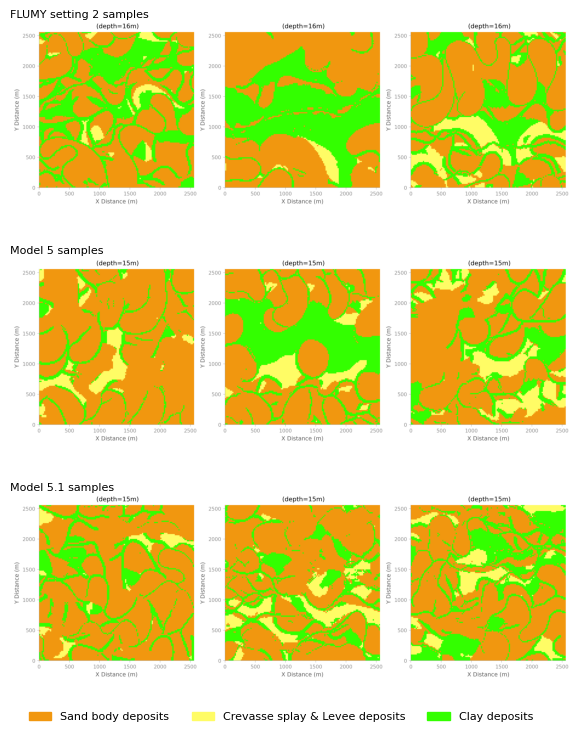

In [ ]:
# Base directory provided in your path
base_dir = r"c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots"

# Manually specify the file names for your 3 rows
image_paths = [
    os.path.join(base_dir, "100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2", "combined_grid_flumy_Z_3samples.png"),  # Row 1 (e.g., FLUMY)Run 1)
    os.path.join(base_dir, "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2", "combined_grid_gan_Z_3samples.png"),     # Row 3 (Modify filename if needed)
    os.path.join(base_dir, "100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2", "combined_grid_gan_Z_3samples.png"),
]

# Titles for each respective row
row_titles = [
    "FLUMY setting 2 samples",
    "Model 5 samples",
    "Model 5.1 samples"
]


legend_config = {
    'names': {
        1: 'Sand body deposits',
        4: 'Crevasse splay & Levee deposits',
        8: 'Clay deposits'
    },
    'colors': {
        1: '#f1970f',
        4: '#fffc65',
        8: '#33ff00'
    }
}

# Create filled block patches for the legend
legend_patches = [
    mpatches.Patch(color=legend_config['colors'][key], label=legend_config['names'][key])
    for key in legend_config['names'].keys()
]

# Setup figure size (adjust width/height ratio depending on your image crops)
fig = plt.figure(figsize=(8.27, 8.27))

# Create a 3x1 grid layout
gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.25)

for i in range(3):
    ax = fig.add_subplot(gs[i, 0])
    
    # Check if the image file exists before trying to load it
    if os.path.exists(image_paths[i]):
        img = mpimg.imread(image_paths[i])
        ax.imshow(img)
    else:
        # Placeholder text if a path is incorrect
        ax.text(0.5, 0.5, f"Missing Image:\n{os.path.basename(image_paths[i])}", 
                ha='center', va='center', color='red', fontsize=12)
    
    # Hide the subplot axes/ticks since we are displaying a pre-saved image
    ax.axis('off')
    
    # Add your requested left-aligned title
    ax.set_title(row_titles[i], loc='left', fontsize=8, pad=2)

# Add the legend horizontally at the bottom center of the figure
fig.legend(
    handles=legend_patches, 
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    facecolor='white', 
    edgecolor='none',
    fontsize=8,
    bbox_to_anchor=(0.5, 0.02) # Dynamically pin position just below the subplots
)

# Adjust layout to make sure nothing overlaps and space is left for the legend
plt.tight_layout()
fig.subplots_adjust(bottom=0.08) # Moves the bottom margin up to make room for the legend

# Save the master composite image
output_path = os.path.join(base_dir, "master_combined_grid_3x1.png")
plt.savefig(output_path, dpi=400, bbox_inches='tight')
print(f"Master 3x1 plot successfully saved to:\n{output_path}")

plt.show()

## **2D XY plot**

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_17716\50793280.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Master grouped plot successfully saved to:
c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\master_grouped_vertical_6x1.png


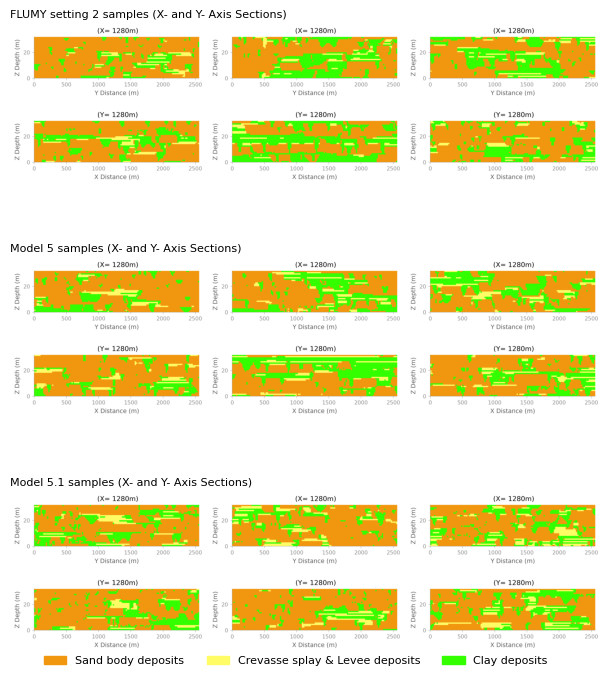

In [ ]:
base_dir = r"c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots"

dir_100_epochs = os.path.join(base_dir, "100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2")
dir_25_epochs = os.path.join(base_dir, "25_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2")

names = [
    "FLUMY setting 2 samples",
    "Model 5 samples",
    "Model 5.1 samples"
]

# Grouped data structure to loop through models cleanly
model_groups = [
    {
        "name": names[0],
        "X_path": os.path.join(dir_100_epochs, "combined_grid_flumy_X_3samples.png"),
        "Y_path": os.path.join(dir_100_epochs, "combined_grid_flumy_Y_3samples.png")
    },
    {
        "name": names[1],
        "X_path": os.path.join(dir_25_epochs, "combined_grid_gan_X_3samples.png"),
        "Y_path": os.path.join(dir_25_epochs, "combined_grid_gan_Y_3samples.png")
    },
    {
        "name": names[2],
        "X_path": os.path.join(dir_100_epochs, "combined_grid_gan_X_3samples.png"),
        "Y_path": os.path.join(dir_100_epochs, "combined_grid_gan_Y_3samples.png")
    }
]

legend_config = {
    'names': {
        1: 'Sand body deposits',
        4: 'Crevasse splay & Levee deposits',
        8: 'Clay deposits'
    },
    'colors': {
        1: '#f1970f',
        4: '#fffc65',
        8: '#33ff00'
    }
}

legend_patches = [
    mpatches.Patch(color=legend_config['colors'][key], label=legend_config['names'][key])
    for key in legend_config['names'].keys()
]

fig = plt.figure(figsize=(8.27, 7.5))

# Outer GridSpec: 3 rows (one for each setting), with a large vertical gap (hspace=0.45)
outer_gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

for i, group in enumerate(model_groups):
    # Inner GridSpec: 2 rows (X and Y plots) nested inside the current outer row cell.
    # We use a tight vertical gap here (hspace=0.08) so X and Y sit close together.
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[i], hspace=0.08)
    
    # ---- Plot 1: X-Axis Cross-Section (Top of group) ----
    ax_x = fig.add_subplot(inner_gs[0, 0])
    if os.path.exists(group["X_path"]):
        img_x = mpimg.imread(group["X_path"])
        ax_x.imshow(img_x)
    else:
        ax_x.text(0.5, 0.5, f"Missing:\n{os.path.basename(group['X_path'])}", 
                  ha='center', va='center', color='red', fontsize=10)
    ax_x.axis('off')
    ax_x.set_title(f"{group['name']} (X- and Y- Axis Sections)", loc='left', fontsize=8, pad=4)
    
    # ---- Plot 2: Y-Axis Cross-Section (Bottom of group) ----
    ax_y = fig.add_subplot(inner_gs[1, 0])
    if os.path.exists(group["Y_path"]):
        img_y = mpimg.imread(group["Y_path"])
        ax_y.imshow(img_y)
    else:
        ax_y.text(0.5, 0.5, f"Missing:\n{os.path.basename(group['Y_path'])}", 
                  ha='center', va='center', color='red', fontsize=10)
    ax_y.axis('off')

fig.legend(
    handles=legend_patches, 
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    facecolor='white', 
    edgecolor='none',
    fontsize=8,
    bbox_to_anchor=(0.5, 0.01)
)

# Render and optimize white margins
plt.tight_layout()
fig.subplots_adjust(bottom=0.04) # Pull up bottom margin to protect the legend layout

# Save target configuration
output_path = os.path.join(base_dir, "master_grouped_vertical_6x1.png")
plt.savefig(output_path, dpi=400, bbox_inches='tight')
print(f"Master grouped plot successfully saved to:\n{output_path}")

plt.show()